# Feature Impact Notebook — Location Intelligence in House Price Prediction

This notebook supports the presentation and answers one central question:

> **How much did location-related features improve the model?**

We compare the **same model family** in two scenarios:

1. **Without location signals**  
   Uses structural house attributes and engineered ratios only.

2. **With location signals**  
   Adds latitude/longitude and zipcode-level demographic enrichment, such as:
   - household income
   - population density
   - education mix
   - urban/suburban mix

## Business message

This is the main business story of the project:

> We stopped treating zipcode as a code and started treating it as a description of the neighborhood.

That allows the model to understand **why** two similar houses may have very different prices.

In [3]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

## 1. Configure paths

Adjust these paths only if your repository layout is different.

This notebook assumes the project datasets are available at:

- `data/raw/kc_house_data.csv`
- `data/raw/zipcode_demographics.csv`

In [7]:
HOUSE_DATA_PATH = Path("../data/raw/kc_house_data.csv")
DEMOGRAPHICS_PATH = Path("../data/raw/zipcode_demographics.csv")

assert HOUSE_DATA_PATH.exists(), f"Missing file: {HOUSE_DATA_PATH}"
assert DEMOGRAPHICS_PATH.exists(), f"Missing file: {DEMOGRAPHICS_PATH}"

HOUSE_DATA_PATH, DEMOGRAPHICS_PATH

(PosixPath('../data/raw/kc_house_data.csv'),
 PosixPath('../data/raw/zipcode_demographics.csv'))

In [8]:
house = pd.read_csv(HOUSE_DATA_PATH)
demo = pd.read_csv(DEMOGRAPHICS_PATH)

house["zipcode"] = house["zipcode"].astype(str)
demo["zipcode"] = demo["zipcode"].astype(str)

print("House rows:", len(house))
print("Demographics rows:", len(demo))

house.head()

House rows: 21613
Demographics rows: 70


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## 3. Merge demographics and create engineered features

These engineered columns mirror the production project story:
- house age
- renovation status
- total square footage
- useful ratios

In [9]:
df = house.merge(demo, on="zipcode", how="left")

reference_year = 2015
df["house_age"] = reference_year - df["yr_built"]
df["renovated_flag"] = (df["yr_renovated"] > 0).astype(int)
df["renovation_age"] = np.where(
    df["yr_renovated"] > 0,
    reference_year - df["yr_renovated"],
    np.nan,
)
df["total_sqft"] = df["sqft_above"] + df["sqft_basement"]
df["living_to_lot_ratio"] = df["sqft_living"] / df["sqft_lot"].replace(0, np.nan)
df["bath_bed_ratio"] = df["bathrooms"] / df["bedrooms"].replace(0, np.nan)
df["basement_ratio"] = df["sqft_basement"] / df["total_sqft"].replace(0, np.nan)

df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,per_assoc,per_bchlr,per_prfsnl,house_age,renovated_flag,renovation_age,total_sqft,living_to_lot_ratio,bath_bed_ratio,basement_ratio
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,5.0,12.0,4.0,60,0,NaN,1180,0.208850,0.333333,0.000000
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,5.0,20.0,12.0,64,1,24.0,2570,0.354874,0.750000,0.155642
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6.0,19.0,9.0,82,0,NaN,770,0.077000,0.500000,0.000000
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7.0,25.0,12.0,50,0,NaN,1960,0.392000,0.750000,0.464286
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,5.0,19.0,7.5,28,0,NaN,1680,0.207921,0.666667,0.000000


## 4. Define the two feature sets

### Base feature set
House structure + condition + engineered ratios

### Location-enhanced feature set
Base features plus:
- `lat`
- `long`
- `zipcode`
- zipcode demographics

In [10]:
base_features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "grade",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated",
    "sqft_living15",
    "sqft_lot15",
    "house_age",
    "renovated_flag",
    "renovation_age",
    "total_sqft",
    "living_to_lot_ratio",
    "bath_bed_ratio",
    "basement_ratio",
]

demographic_features = [c for c in demo.columns if c != "zipcode"]

location_features = [
    "lat",
    "long",
    "zipcode",
] + demographic_features

with_location_features = base_features + location_features

print("Base feature count:", len(base_features))
print("With-location feature count:", len(with_location_features))
print("Extra location-related columns:", len(with_location_features) - len(base_features))

Base feature count: 22
With-location feature count: 51
Extra location-related columns: 29


## 5. Sample for fast, reproducible comparison

For presentation speed, we use a fixed sample from the real dataset.

You can increase `N_SAMPLE` if you want a heavier run.

In [11]:
N_SAMPLE = min(12000, len(df))

sample_df = df.sample(n=N_SAMPLE, random_state=42).copy()

y = np.log1p(sample_df["price"])
X_base = sample_df[base_features]
X_location = sample_df[with_location_features]

Xb_train, Xb_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)
Xl_train, Xl_test, _, _ = train_test_split(
    X_location, y, test_size=0.2, random_state=42
)

print("Sample size:", len(sample_df))
print("Train rows:", len(Xb_train))
print("Test rows:", len(Xb_test))

Sample size: 12000
Train rows: 9600
Test rows: 2400


## 6. Build the comparison pipelines

We use the same model family in both scenarios:

- `HistGradientBoostingRegressor`

This isolates the effect of the **features**, not the algorithm.

In [12]:
def make_histgb_pipeline(feature_frame: pd.DataFrame) -> Pipeline:
    categorical_cols = [c for c in feature_frame.columns if feature_frame[c].dtype == "object"]
    numeric_cols = [c for c in feature_frame.columns if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_cols),
            (
                "cat",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
                    ]
                ),
                categorical_cols,
            ),
        ],
        remainder="drop",
    )

    model = HistGradientBoostingRegressor(
        random_state=42,
        max_iter=120,
        learning_rate=0.05,
        max_depth=None,
    )

    return Pipeline(
        [
            ("preprocessor", preprocessor),
            ("model", model),
        ]
    )

In [14]:
pipe_base = make_histgb_pipeline(Xb_train)
pipe_loc = make_histgb_pipeline(Xl_train)

pipe_base.fit(Xb_train, y_train)
pipe_loc.fit(Xl_train, y_train)

pred_base = np.expm1(pipe_base.predict(Xb_test))
pred_loc = np.expm1(pipe_loc.predict(Xl_test))
y_true = np.expm1(y_test)

def metric_row(label: str, pred: np.ndarray) -> dict:
    rmse = mean_squared_error(y_true, pred) ** 0.5
    return {
        "Scenario": label,
        "MAE": float(mean_absolute_error(y_true, pred)),
        "RMSE": float(rmse),
        "R2": float(r2_score(y_true, pred)),
    }

results = pd.DataFrame(
    [
        metric_row("Without location signals", pred_base),
        metric_row("With location signals", pred_loc),
    ]
)

results["MAE Improvement vs Base"] = results["MAE"].iloc[0] - results["MAE"]
results["RMSE Improvement vs Base"] = results["RMSE"].iloc[0] - results["RMSE"]
results["R2 Gain vs Base"] = results["R2"] - results["R2"].iloc[0]

results

,Scenario,MAE,RMSE,R2,MAE Improvement vs Base,RMSE Improvement vs Base,R2 Gain vs Base
0,Without location signals,118462.179325,198986.522815,0.707758,0.00000,0.000000,0.000000
1,With location signals,68465.608865,124962.741608,0.884746,49996.57046,74023.781207,0.176988


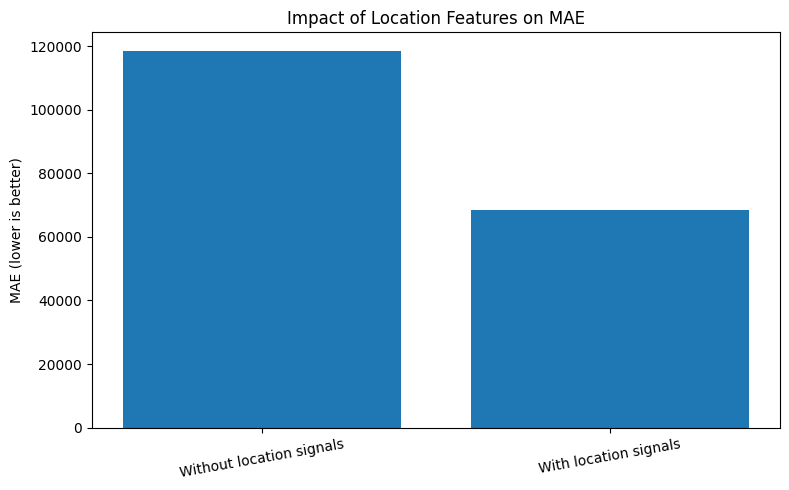

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(results["Scenario"], results["MAE"])
plt.title("Impact of Location Features on MAE")
plt.ylabel("MAE (lower is better)")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

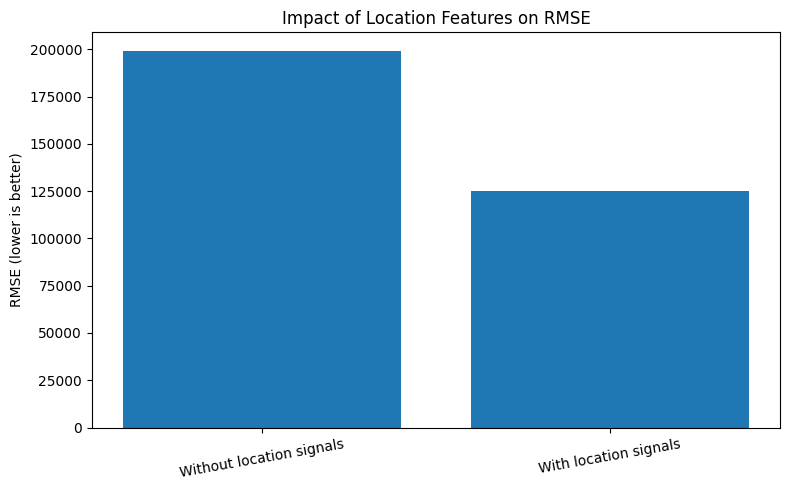

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(results["Scenario"], results["RMSE"])
plt.title("Impact of Location Features on RMSE")
plt.ylabel("RMSE (lower is better)")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## 9. Which features matter most?

We use permutation importance on the **location-enhanced model** to identify the strongest signals.

This is useful for showing that the model is not only using house size, but also neighborhood context.

In [17]:
perm = permutation_importance(
    pipe_loc,
    Xl_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring="neg_mean_absolute_error",
)

importance_df = pd.DataFrame(
    {
        "feature": Xl_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }
).sort_values("importance_mean", ascending=False)

importance_df.head(15)

,feature,importance_mean,importance_std
22,lat,0.093923,0.001159
2,sqft_living,0.092441,0.001908
8,grade,0.066135,0.000727
49,per_bchlr,0.021621,0.001526
32,hous_val_amt,0.012836,0.001084
50,per_prfsnl,0.011757,0.000949
23,long,0.009053,0.000915
13,sqft_living15,0.007199,0.000446
6,view,0.007043,0.000532
3,sqft_lot,0.006275,0.000239


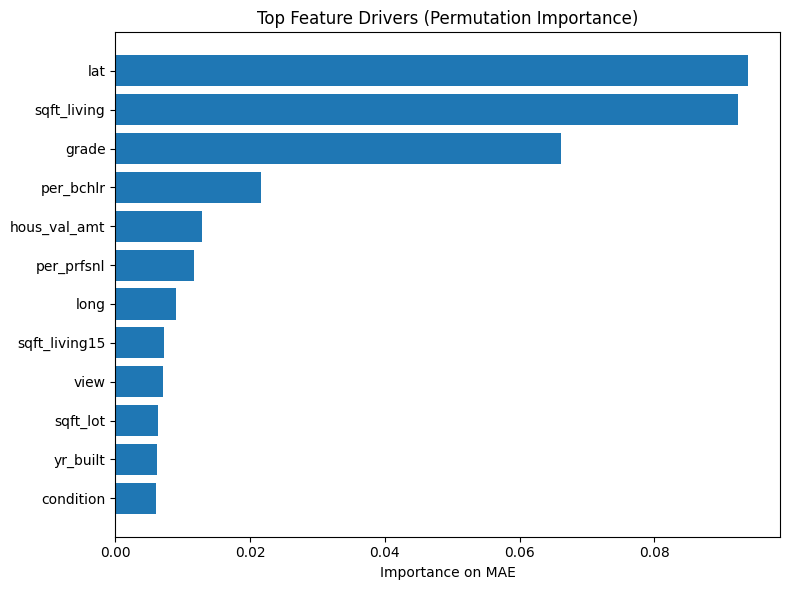

In [18]:
top_n = 12
top_df = importance_df.head(top_n).sort_values("importance_mean")

plt.figure(figsize=(8, 6))
plt.barh(top_df["feature"], top_df["importance_mean"])
plt.title("Top Feature Drivers (Permutation Importance)")
plt.xlabel("Importance on MAE")
plt.tight_layout()
plt.show()